# PINN_z model visualizer

Vælg en model i konfigurationscellen og plot et helt x-z-billede for `target`, `prediction`, `da_loss` og `eq_loss`.

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch


def find_root_dir() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "SciML").exists() and (candidate / "Experimenter").exists():
            return candidate.resolve()
    raise RuntimeError("Kunne ikke finde projektroden fra den nuværende working directory.")


ROOT_DIR = find_root_dir()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from hesel_scraper.bout_dump import BOUTHESELInfo
from hesel_scraper.bout_phys import BOUTHESELPhys
from SciML.PINN_z.utils.training_helpers import load_checkpoint
from SciML.PINN_z.utils.wrapper import WrappedPINN


FIELDS = ("lnn", "lnpe", "lnpi", "phi")
AVG_FIELDS = ("avg_n", "avg_te", "avg_ti", "avg_phi")
EQ_KEYS = {
    "lnn": "eq_lnn",
    "lnpe": "eq_lnpe",
    "lnpi": "eq_lnpi",
    "phi": "eq_vort",
}
MODEL_DIRS = {
    path.name: path
    for path in sorted((ROOT_DIR / "Experimenter" / "PINN_z").glob("Eksperiment_*"))
    if (path / "checkpoint.pt").exists()
}


def strip_state_dict_metadata(state_dict):
    if state_dict is None:
        return None
    if "_metadata" in state_dict:
        state_dict = dict(state_dict)
        state_dict.pop("_metadata", None)
    return state_dict


def normalize_checkpoint_path(path: Path | str) -> Path:
    path = Path(path)
    if path.is_dir():
        path = path / "checkpoint.pt"
    return path.resolve()


def load_model_bundle(checkpoint_dir, dataset_root=None, state_dict_key="best_val_model"):
    checkpoint_path = normalize_checkpoint_path(checkpoint_dir)
    checkpoint = load_checkpoint({"data_dir": checkpoint_path.parent})
    train_cfg = checkpoint["training_config"]

    if dataset_root is None:
        dataset_root = Path(train_cfg["root"][0]).resolve()
    else:
        dataset_root = Path(dataset_root).resolve()

    info = BOUTHESELInfo(dataset_root)
    phys = BOUTHESELPhys(info)
    model = WrappedPINN(
        info=info,
        phys=phys,
        m=train_cfg["z_width"],
        network_structure=train_cfg["network"],
    ).to(info.device)

    state_dict = checkpoint.get(state_dict_key)
    if state_dict is None and state_dict_key != "model_state_dict":
        state_dict = checkpoint.get("model_state_dict")
    state_dict = strip_state_dict_metadata(state_dict)
    if state_dict is None:
        raise KeyError(
            f"Checkpoint mangler både '{state_dict_key}' og 'model_state_dict'."
        )

    model.load_state_dict(state_dict)
    model.eval()
    return checkpoint, train_cfg, info, phys, model, dataset_root


def collect_prediction_inputs(info, target_t: int, z_width: int):
    if target_t < 2:
        raise ValueError("target_t skal være mindst 2, fordi modellen bruger t-2 og t-1 som input.")

    data = torch.stack(
        [getattr(info.data, field_name)[:, 1:-1].to(info.device) for field_name in FIELDS],
        dim=1,
    )

    if target_t >= data.shape[0]:
        raise ValueError(f"target_t={target_t} er uden for intervallet [2, {data.shape[0] - 1}].")

    avg_z_full = torch.stack(
        [info.avg_in_z[field_name].squeeze(-1)[:, 1:-1].to(info.device) for field_name in AVG_FIELDS],
        dim=1,
    )

    z_half = z_width // 2
    z_offsets = torch.arange(-z_half, z_half + 1, device=info.device)
    nx = info.parameters.num_x - 2
    nz = info.parameters.num_z
    coords = []
    windows = []

    for z_idx in range(nz):
        window_t0 = data[target_t - 2, :, :, (z_idx + z_offsets) % nz]
        window_t1 = data[target_t - 1, :, :, (z_idx + z_offsets) % nz]
        windows.append(torch.cat([window_t0, window_t1], dim=0))
        coords.append(
            torch.tensor(
                [info.parameters.dz * z_idx, info.parameters.dt * target_t],
                device=info.device,
                dtype=info.dtype,
            )
        )

    avg_z = avg_z_full[target_t].unsqueeze(0).unsqueeze(-1).expand(nz, -1, -1, -1)
    x_idx = torch.arange(nx, device=info.device, dtype=torch.long).view(1, nx, 1).expand(nz, -1, 1)
    z_idx_tensor = torch.arange(nz, device=info.device, dtype=torch.long).view(nz, 1, 1).expand(-1, nx, 1)
    t_idx_tensor = torch.full((nz, nx, 1), target_t, device=info.device, dtype=torch.long)
    coords_num = torch.stack([x_idx, z_idx_tensor, t_idx_tensor], dim=1)

    return data, torch.stack(windows), torch.stack(coords), avg_z, coords_num


def predict_full_image(model, phys, info, target_t: int, z_width: int):
    data, u_batch, coord_batch, avg_z, coords_num = collect_prediction_inputs(info, target_t=target_t, z_width=z_width)
    old_requires_grad = [param.requires_grad for param in model.parameters()]
    for param in model.parameters():
        param.requires_grad_(False)

    try:
        prediction_dict, coord_fys = model([u_batch, None, None, coord_batch, coords_num], requires_coord_grad=True)
        eq_residual_dict = phys.eq_res(avg_z, prediction_dict, coord_fys, coords_num)
    finally:
        for param, old_value in zip(model.parameters(), old_requires_grad):
            param.requires_grad_(old_value)

    prediction = {
        field_name: prediction_dict[field_name].squeeze(1).squeeze(-1).transpose(0, 1)
        for field_name in FIELDS
    }
    target = {
        field_name: data[target_t, field_idx]
        for field_idx, field_name in enumerate(FIELDS)
    }
    da_loss = {
        field_name: (target[field_name] - prediction[field_name]).pow(2)
        for field_name in FIELDS
    }
    eq_loss = {
        field_name: eq_residual_dict[EQ_KEYS[field_name]].squeeze(1).squeeze(-1).transpose(0, 1).pow(2)
        for field_name in FIELDS
    }
    return target, prediction, da_loss, eq_loss


def normalize_fields(fields=None):
    if fields is None:
        return list(FIELDS)
    if isinstance(fields, str):
        return [fields]
    return list(fields)


def plot_full_image(checkpoint_dir, fields=None, target_t=10, dataset_root=None, state_dict_key="best_val_model", figsize=None):
    checkpoint, train_cfg, info, phys, model, dataset_root = load_model_bundle(
        checkpoint_dir=checkpoint_dir,
        dataset_root=dataset_root,
        state_dict_key=state_dict_key,
    )

    fields = normalize_fields(fields)
    invalid_fields = [field for field in fields if field not in FIELDS]
    if invalid_fields:
        raise ValueError(f"Ukendte felter: {invalid_fields}. Gyldige felter er {FIELDS}.")

    target_dict, prediction_dict, da_loss_dict, eq_loss_dict = predict_full_image(
        model=model,
        phys=phys,
        info=info,
        target_t=target_t,
        z_width=train_cfg["z_width"],
    )

    if figsize is None:
        figsize = (20, 4.0 * len(fields))

    fig, axes = plt.subplots(len(fields), 4, figsize=figsize, constrained_layout=True, squeeze=False)
    result = {
        "checkpoint": checkpoint,
        "train_cfg": train_cfg,
        "dataset_root": dataset_root,
        "target": {},
        "prediction": {},
        "da_loss": {},
        "eq_loss": {},
    }

    for row_idx, field in enumerate(fields):
        target = target_dict[field].detach().cpu()
        prediction = prediction_dict[field].detach().cpu()
        da_loss = da_loss_dict[field].detach().cpu()
        eq_loss = eq_loss_dict[field].detach().cpu()
        result["target"][field] = target
        result["prediction"][field] = prediction
        result["da_loss"][field] = da_loss
        result["eq_loss"][field] = eq_loss

        value_min = min(float(target.min()), float(prediction.min()))
        value_max = max(float(target.max()), float(prediction.max()))
        da_loss_max = float(da_loss.max())
        eq_loss_max = float(eq_loss.max())
        image_specs = [
            (target, f"{field} target", "viridis", value_min, value_max),
            (prediction, f"{field} prediction", "viridis", value_min, value_max),
            (da_loss, f"{field} da_loss", "magma", 0.0, da_loss_max),
            (eq_loss, f"{field} eq_loss", "magma", 0.0, eq_loss_max),
        ]

        for ax, (image, title, cmap, vmin, vmax) in zip(axes[row_idx], image_specs):
            im = ax.imshow(image.T, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.set_xlabel("x index")
            ax.set_ylabel("z index")
            fig.colorbar(im, ax=ax)

    fig.suptitle(
        f"{Path(checkpoint_dir).name} | {dataset_root.name} | fields={fields} | t={target_t}",
        y=1.03,
    )
    return fig, axes, result


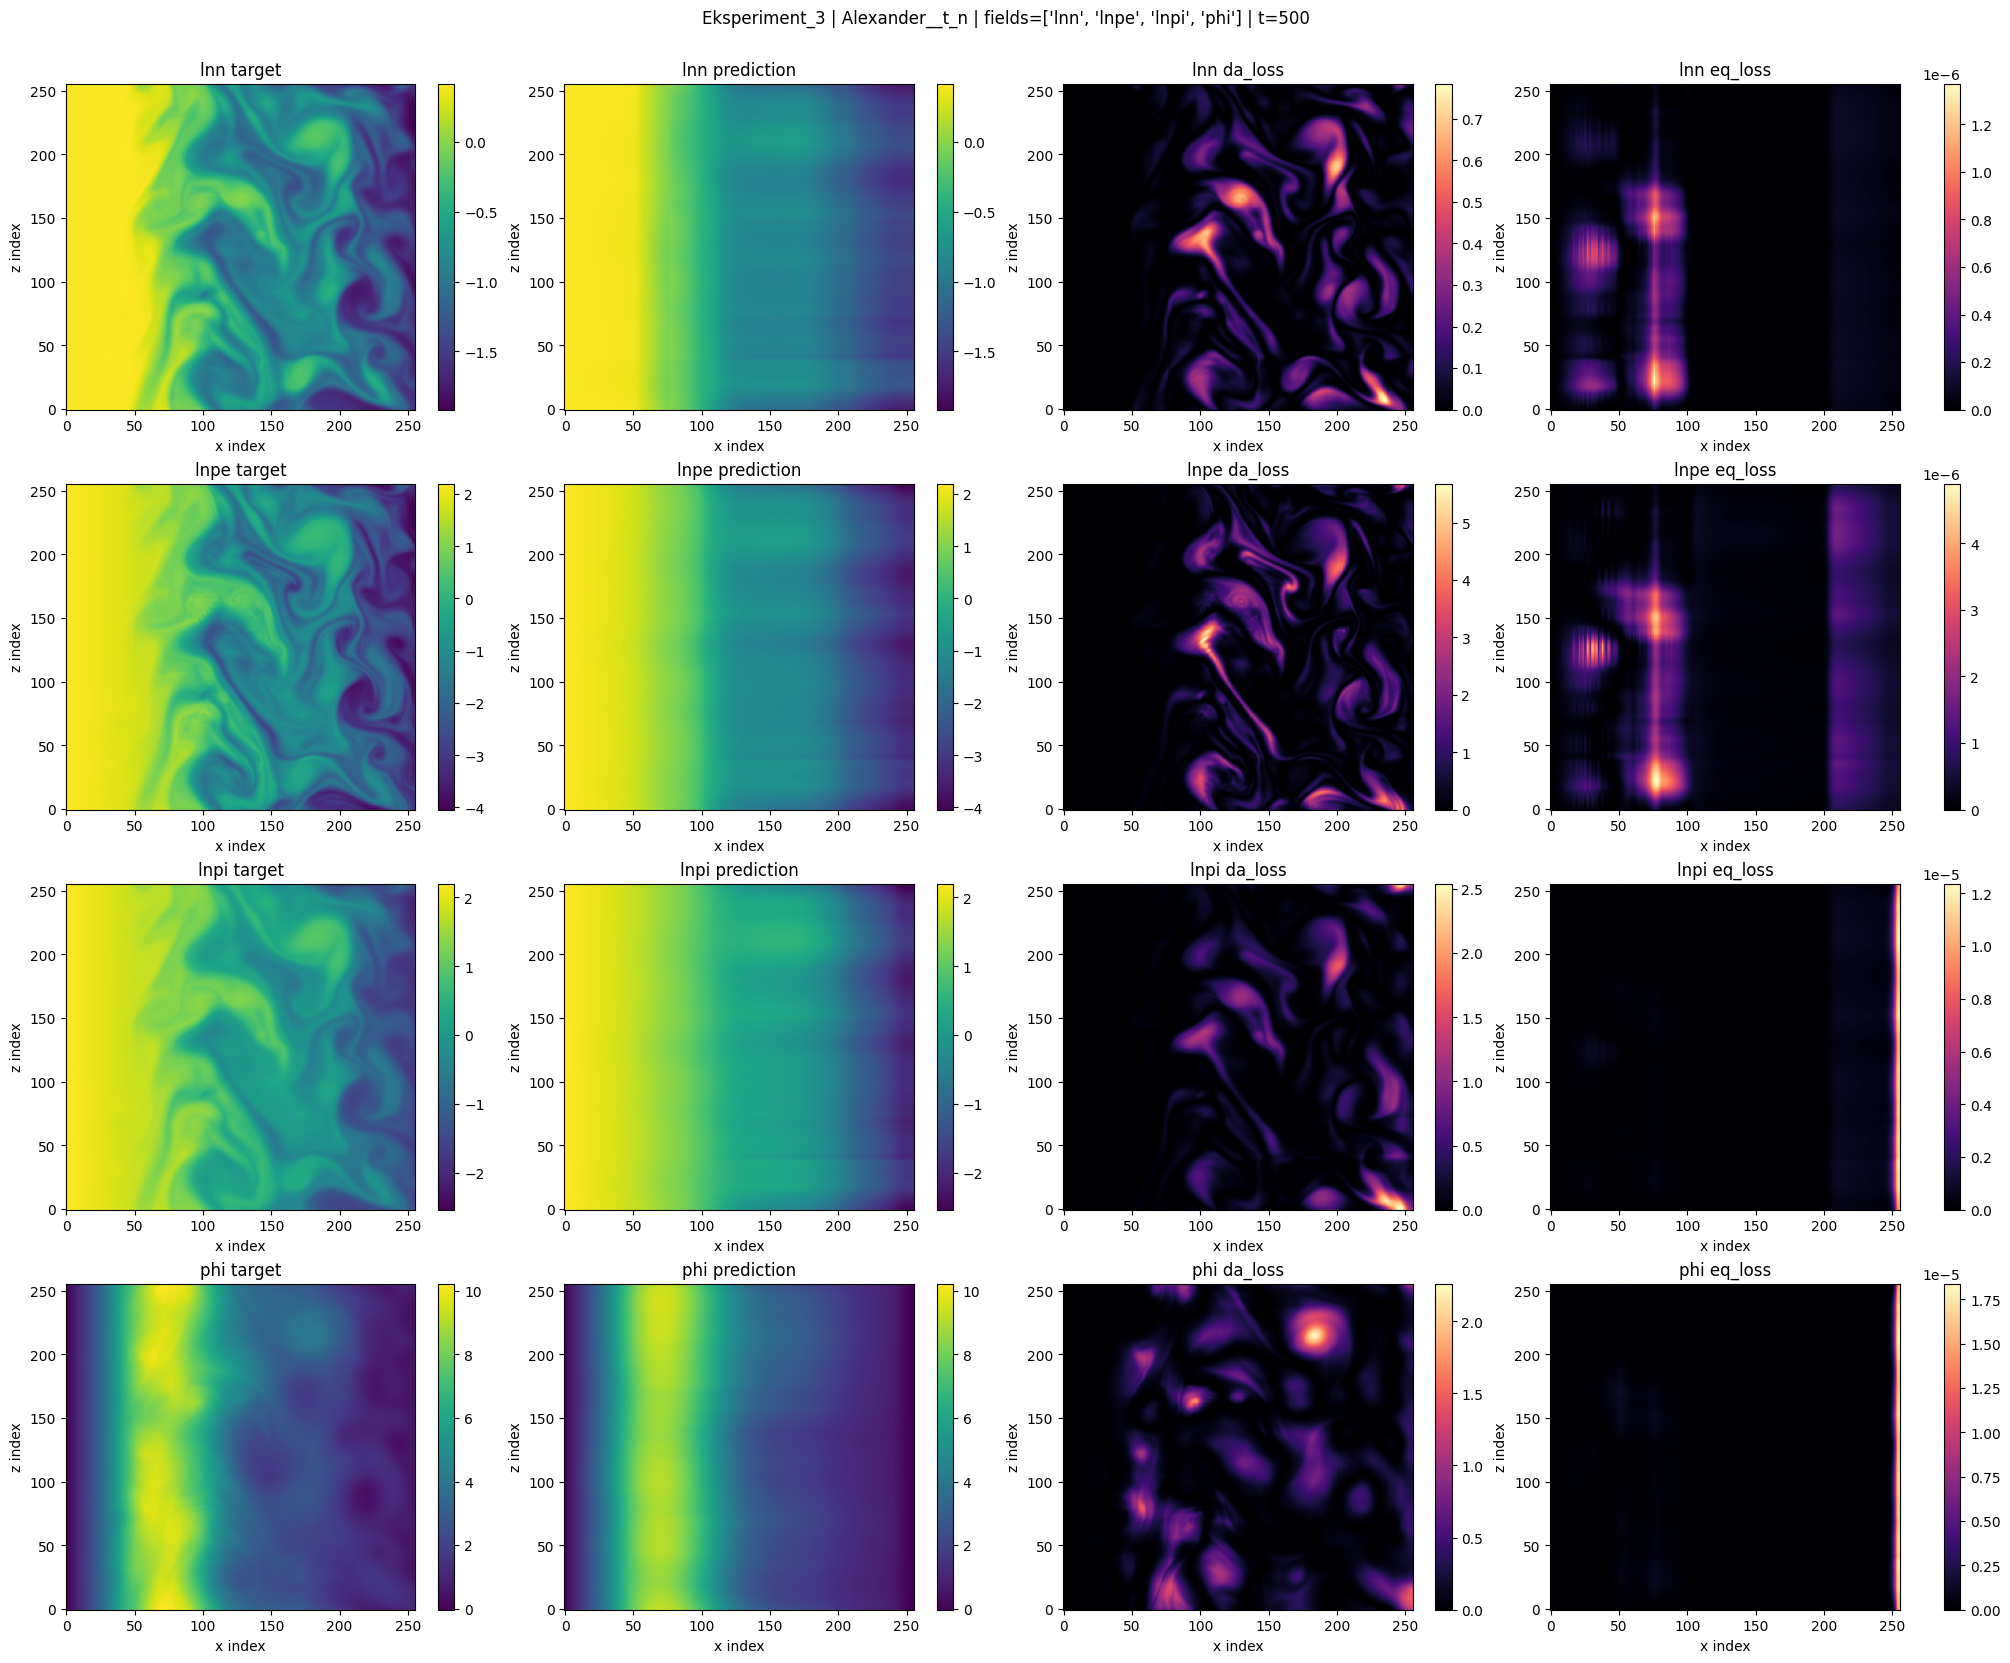

In [10]:
# Vælg én model herfra:
MODEL_DIRS

MODEL_NAME = "Eksperiment_3"
DATASET_ROOT = ROOT_DIR / "sim_data" / "Alexander__t_n" #. None bruger checkpointets første root.
FIELDS_TO_PLOT = None  # None plotter alle fields. Fx ["lnn", "phi"] for et udvalg.
TARGET_T = 500
STATE_DICT_KEY = "best_val_model"

fig, axes, result = plot_full_image(
    checkpoint_dir=MODEL_DIRS[MODEL_NAME],
    dataset_root=DATASET_ROOT,
    fields=FIELDS_TO_PLOT,
    target_t=TARGET_T, 
    state_dict_key=STATE_DICT_KEY,
)
plt.show()
